In [46]:
# esta práctica consiste en detectar el objeto más grande y el más pequeño en una imagen 

In [47]:
# librerias
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage

In [48]:
# leer imágenes
img1 = cv2.imread('img/img1.jpg')
img2 = cv2.imread('img/img2.png')
img3 = cv2.imread('img/img3.jpg')
img4 = cv2.imread('img/img4.jpg')

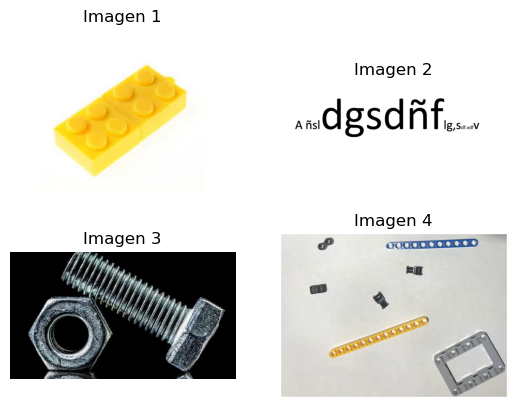

In [49]:
# imprimir las img
for i in range(1, 5):
    plt.subplot(2, 2, i)
    plt.imshow(cv2.cvtColor(eval(f'img{i}'), cv2.COLOR_BGR2RGB))
    plt.title(f'Imagen {i}')
    plt.axis('off')
plt.show()

In [50]:
# convertir a escala de grises
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
gray4 = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)

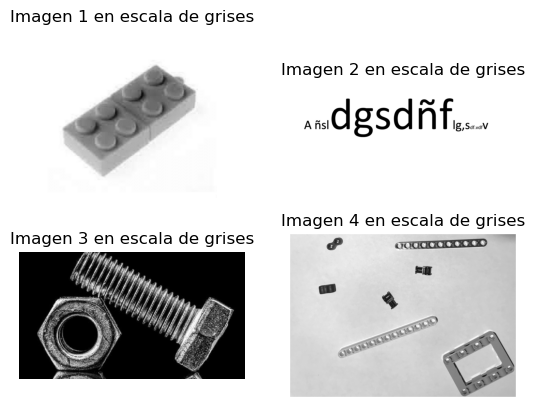

In [51]:
# mostrar las imágenes en escala de grises
for i in range(1,5):
    plt.subplot(2, 2, i)
    plt.imshow(eval(f'gray{i}'), cmap='gray')
    plt.title(f'Imagen {i} en escala de grises')
    plt.axis('off')
plt.show()

In [52]:
# convertir a vectores de una dimensión
vector1 = gray1.flatten()
vector2 = gray2.flatten()
vector3 = gray3.flatten()
vector4 = gray4.flatten()

In [53]:
# umbral otsu
umbral1, _ = cv2.threshold(gray1, 0, 255, cv2.THRESH_OTSU)
umbral2, _ = cv2.threshold(gray2, 0, 255, cv2.THRESH_OTSU)
umbral3, _ = cv2.threshold(gray3, 0, 255, cv2.THRESH_OTSU)
umbral4, _ = cv2.threshold(gray4, 0, 255, cv2.THRESH_OTSU)

In [54]:
# binarias 
binaria1 = np.uint8((gray1 < umbral1) * 255)
binaria2 = np.uint8((gray2 < umbral2) * 255)
binaria3 = np.uint8((gray3 < umbral3) * 255)
binaria4 = np.uint8((gray4 < umbral4) * 255)

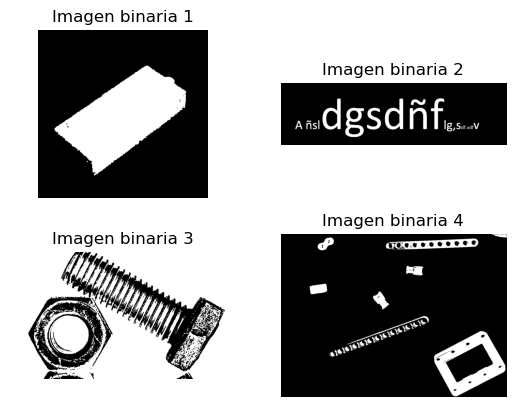

In [55]:
# mostrar las imágenes binarias
for i in range(1, 5):
    plt.subplot(2, 2, i)
    plt.imshow(eval(f'binaria{i}'), cmap='gray')
    plt.title(f'Imagen binaria {i}')
    plt.axis('off')
plt.show()

In [56]:
# análisis de componentes conectados
salida1 = cv2.connectedComponentsWithStats(binaria1, connectivity=4, ltype=cv2.CV_32S)
salida2 = cv2.connectedComponentsWithStats(binaria2, connectivity=4, ltype=cv2.CV_32S)
salida3 = cv2.connectedComponentsWithStats(binaria3, connectivity=4, ltype=cv2.CV_32S)
salida4 = cv2.connectedComponentsWithStats(binaria4, connectivity=4, ltype=cv2.CV_32S)

cantidad_componentes1, etiquetas1, estadisticas1, _ = salida1
cantidad_componentes2, etiquetas2, estadisticas2, _ = salida2
cantidad_componentes3, etiquetas3, estadisticas3, _ = salida3
cantidad_componentes4, etiquetas4, estadisticas4, _ = salida4

print("Cantidad de componentes conectados en la imagen 1:", cantidad_componentes1)
print("Cantidad de componentes conectados en la imagen 2:", cantidad_componentes2)
print("Cantidad de componentes conectados en la imagen 3:", cantidad_componentes3)
print("Cantidad de componentes conectados en la imagen 4:", cantidad_componentes4)

Cantidad de componentes conectados en la imagen 1: 6
Cantidad de componentes conectados en la imagen 2: 24
Cantidad de componentes conectados en la imagen 3: 596
Cantidad de componentes conectados en la imagen 4: 120


In [57]:
# encontrar el objeto con mayor área (cuarta columna)
mascara_grande1 = (np.argmax(estadisticas1[1:, 4]) + 1 == etiquetas1).astype(int)
mascara_grande2 = (np.argmax(estadisticas2[1:, 4]) + 1 == etiquetas2).astype(int)
mascara_grande3 = (np.argmax(estadisticas3[1:, 4]) + 1 == etiquetas3).astype(int)
mascara_grande4 = (np.argmax(estadisticas4[1:, 4]) + 1 == etiquetas4).astype(int)

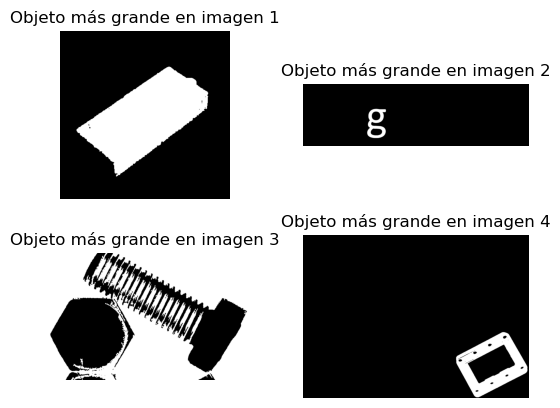

In [58]:
# mostrar la mascara del objeto más grande de todas las imágenes
for i in range(1, 5):
    plt.subplot(2, 2, i)
    plt.imshow(eval(f'mascara_grande{i}'), cmap='gray')
    plt.title(f'Objeto más grande en imagen {i}')
    plt.axis('off')

In [ ]:
# hacemos una función para tener la mascara del objeto más grande o más pequeño de una imagen binaria, con limpieza y llenado de huecos internos
def extraer_mascara_objetos(binaria, modo='grande', area_minima=50):
    # limpieza
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)) # ajusta el tamaño según el ruido esperado
    binaria_limpia = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, kernel) # elimina ruido pequeño
    
    # analisis de componentes conectados
    num_labels, etiquetas, estadisticas, _ = cv2.connectedComponentsWithStats(binaria_limpia, 8, cv2.CV_32S)
    
    # si no hay objetos, retornar máscara vacía
    if num_labels <= 1: return np.zeros_like(binaria)

    alto, ancho = binaria.shape
    candidatos = []

    # filtrar objetos por área mínima y si tocan el borde
    for i in range(1, num_labels):
        x, y, w, h, area = estadisticas[i]
        # ignorar objetos que tocan el borde (suelen estar incompletos)
        toca_borde = (x == 0) or (y == 0) or (x + w >= ancho) or (y + h >= alto)
        
        if not toca_borde and area > area_minima:
            candidatos.append({'id': i, 'area': area})

    if not candidatos: # si todos tocan borde, entonces tomar el mejor disponible
        candidatos = [{'id': i, 'area': estadisticas[i, 4]} for i in range(1, num_labels)]

    # seleccionar según el modo
    if modo == 'grande':
        elegido = max(candidatos, key=lambda x: x['area'])
    else:
        elegido = min(candidatos, key=lambda x: x['area'])

    # crear mascara del objeto elegido
    mascara = (etiquetas == elegido['id']).astype(np.uint8) * 255
    mascara = ndimage.binary_fill_holes(mascara > 0).astype(np.uint8) * 255
    
    return mascara

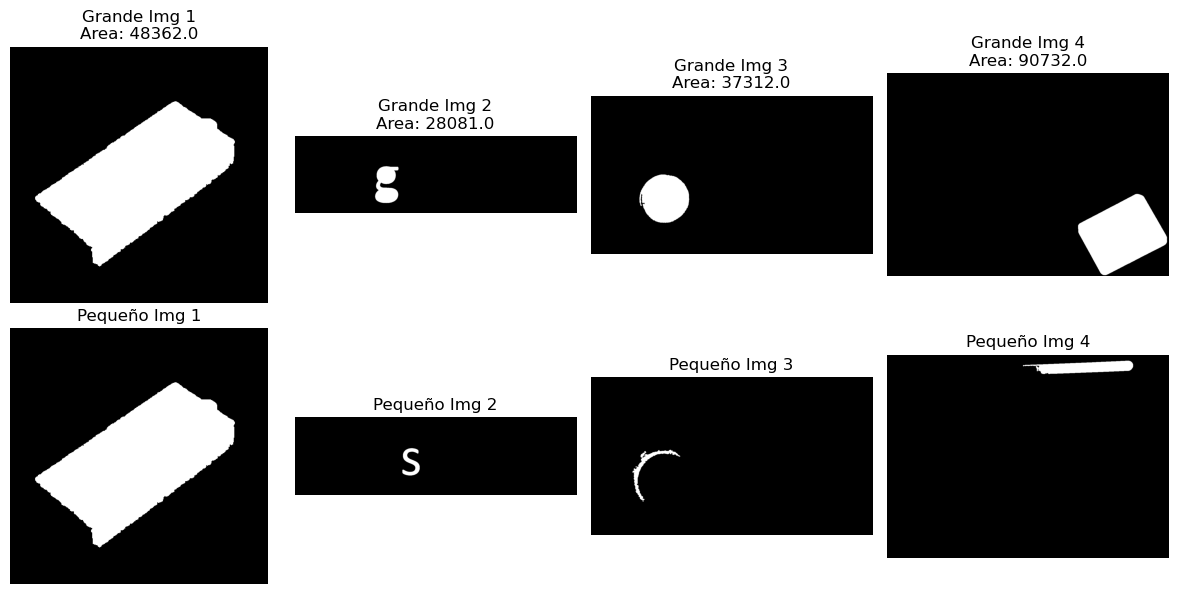

In [60]:
# ls para guardar resultados y mostrarlos fácilmente
mascaras_grandes = []
mascaras_pequenas = []
datos_finales = []

for i in range(1, 5):
    # Recuperamos tus variables binarias (binaria1, binaria2...)
    bin_actual = eval(f'binaria{i}')
    
    # máscaras mejoradas
    m_grande = extraer_mascara_objetos(bin_actual, modo='grande')
    m_peque = extraer_mascara_objetos(bin_actual, modo='pequeno')
    
    mascaras_grandes.append(m_grande)
    mascaras_pequenas.append(m_peque)
    
    # calcular métricas precisas del objeto grande
    cnts, _ = cv2.findContours(m_grande, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # contornos del objeto grande
    if cnts: # si hay contornos encontrados
        cnt = max(cnts, key=cv2.contourArea) # tomar el contorno más grande (debería ser el único)
        area = cv2.contourArea(cnt)
        perimetro = cv2.arcLength(cnt, True)
        datos_finales.append((area, perimetro))

# visualización (Siguiendo tu estilo de subplots)
plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(mascaras_grandes[i], cmap='gray')
    plt.title(f'Grande Img {i+1}\nArea: {datos_finales[i][0]:.1f}')
    plt.axis('off')
    
    plt.subplot(2, 4, i+5)
    plt.imshow(mascaras_pequenas[i], cmap='gray')
    plt.title(f'Pequeño Img {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()